In [1]:
# =====================================================================
# CNN-Based Offline Signature Forgery Detection Using the CEDAR Dataset
# Custom CNN vs. Pretrained MobileNetV2  (CPU-only, reproducible)
# =====================================================================

# These environment variables must be set BEFORE TensorFlow is imported.
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # more deterministic CPU math
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"    # hide verbose TF info logs

import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("Imports completed successfully.")

Imports completed successfully.


In [2]:
SEED = 42

def set_seeds(seed=SEED):
    """Set every relevant random seed. Called again before each model is built."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)   # sets Python, NumPy and TF seeds together

set_seeds(SEED)

# Ask TensorFlow to use deterministic operations where possible
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow op determinism: ENABLED")
except Exception as e:
    print("Could not enable op determinism:", e)

print(f"SEED = {SEED}")
print("Seeds set for: Python random, NumPy, TensorFlow, PYTHONHASHSEED")

TensorFlow op determinism: ENABLED
SEED = 42
Seeds set for: Python random, NumPy, TensorFlow, PYTHONHASHSEED


In [3]:
print("Python version     :", sys.version.split()[0])
print("TensorFlow version :", tf.__version__)
print("Keras version      :", keras.__version__)
print("NumPy version      :", np.__version__)
print("Working directory  :", Path.cwd())

gpus = tf.config.list_physical_devices("GPU")
cpus = tf.config.list_physical_devices("CPU")
print("\nCPU devices:", cpus)
print("GPU devices:", gpus if gpus else "None (running on CPU only)")

Python version     : 3.13.2
TensorFlow version : 2.21.0
Keras version      : 3.14.0
NumPy version      : 2.2.4
Working directory  : C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project

CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU devices: None (running on CPU only)


In [5]:
BASE_DIR     = Path.cwd()
DATASET_DIR  = BASE_DIR / "CEDAR"
GENUINE_DIR  = DATASET_DIR / "full_org"
FORGED_DIR   = DATASET_DIR / "full_forg"

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg"}

IMG_WIDTH  = 128
IMG_HEIGHT = 64

LABEL_GENUINE = 0
LABEL_FORGED  = 1
CLASS_NAMES   = ["Genuine", "Forged"]

print("Dataset folder :", DATASET_DIR)
print("Genuine folder :", GENUINE_DIR)
print("Forged folder  :", FORGED_DIR)

Dataset folder : C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project\CEDAR
Genuine folder : C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project\CEDAR\full_org
Forged folder  : C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project\CEDAR\full_forg


In [6]:
for name, folder in [("CEDAR", DATASET_DIR),
                     ("Genuine (full_org)", GENUINE_DIR),
                     ("Forged (full_forg)", FORGED_DIR)]:
    exists = folder.is_dir()
    print(f"{name:<20} exists: {exists}")
    if not exists:
        raise FileNotFoundError(
            f"Folder not found: {folder}\n"
            "Make sure this notebook is in the Project folder next to the CEDAR folder."
        )

print("\nAll dataset folders found.")

CEDAR                exists: True
Genuine (full_org)   exists: True
Forged (full_forg)   exists: True

All dataset folders found.


In [7]:
def list_image_files(folder):
    """Return a sorted list of valid image files (.png/.jpg/.jpeg) inside a folder."""
    files = [p for p in folder.rglob("*")
             if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS]
    return sorted(files)

genuine_files = list_image_files(GENUINE_DIR)
forged_files  = list_image_files(FORGED_DIR)

print(f"Genuine image files found : {len(genuine_files)}")
print(f"Forged image files found  : {len(forged_files)}")
print(f"Total image files         : {len(genuine_files) + len(forged_files)}")

if len(genuine_files) == 0 or len(forged_files) == 0:
    raise ValueError("No images found in one of the folders. Check the dataset paths.")

Genuine image files found : 1320
Forged image files found  : 1320
Total image files         : 2640


In [8]:
def load_and_preprocess(path, width=IMG_WIDTH, height=IMG_HEIGHT):
    """
    Load one signature image and return a float32 array of shape (height, width)
    with pixel values in [0, 1].
    Steps: open with PIL -> grayscale -> resize -> NumPy -> normalize.
    """
    with Image.open(path) as img:
        img = img.convert("L")                                   # grayscale
        img = img.resize((width, height), Image.Resampling.LANCZOS)  # (width, height)
        arr = np.asarray(img, dtype=np.float32)
    return arr / 255.0                                           # normalize to [0, 1]

# Quick test on one file
test_arr = load_and_preprocess(genuine_files[0])
print("Test array shape :", test_arr.shape)
print("Test array dtype :", test_arr.dtype)
print(f"Value range      : {test_arr.min():.3f} to {test_arr.max():.3f}")

Test array shape : (64, 128)
Test array dtype : float32
Value range      : 0.380 to 1.000


In [9]:
def load_class(files, label, class_name):
    images, labels, skipped = [], [], []
    for i, path in enumerate(files, start=1):
        try:
            images.append(load_and_preprocess(path))
            labels.append(label)
        except Exception as e:
            skipped.append((path.name, str(e)))
        if i % 500 == 0:
            print(f"  {class_name}: processed {i}/{len(files)}")
    return images, labels, skipped

print("Loading genuine signatures...")
gen_imgs, gen_lbls, gen_skipped = load_class(genuine_files, LABEL_GENUINE, "Genuine")
print("Loading forged signatures...")
for_imgs, for_lbls, for_skipped = load_class(forged_files, LABEL_FORGED, "Forged")

X = np.array(gen_imgs + for_imgs, dtype=np.float32)
y = np.array(gen_lbls + for_lbls, dtype=np.int32)

skipped_files = gen_skipped + for_skipped
print(f"\nSkipped (unreadable) files: {len(skipped_files)}")
for name, err in skipped_files[:5]:
    print("  ", name, "->", err)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print(f"X dtype: {X.dtype} | value range: {X.min():.3f} to {X.max():.3f}")

# free temporary lists
del gen_imgs, for_imgs, gen_lbls, for_lbls

Loading genuine signatures...
  Genuine: processed 500/1320
  Genuine: processed 1000/1320
Loading forged signatures...
  Forged: processed 500/1320
  Forged: processed 1000/1320

Skipped (unreadable) files: 0

X shape: (2640, 64, 128)
y shape: (2640,)
X dtype: float32 | value range: 0.110 to 1.000


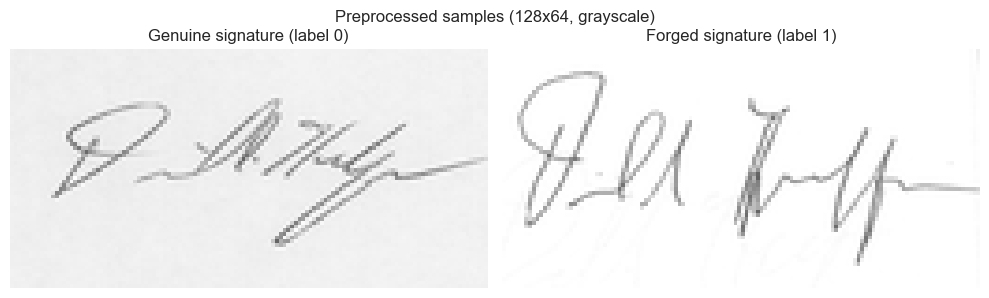

In [10]:
idx_genuine = int(np.where(y == LABEL_GENUINE)[0][0])
idx_forged  = int(np.where(y == LABEL_FORGED)[0][0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].imshow(X[idx_genuine], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Genuine signature (label 0)")
axes[0].axis("off")

axes[1].imshow(X[idx_forged], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Forged signature (label 1)")
axes[1].axis("off")

plt.suptitle(f"Preprocessed samples ({IMG_WIDTH}x{IMG_HEIGHT}, grayscale)")
plt.tight_layout()
plt.show()

Genuine    1320
Forged     1320


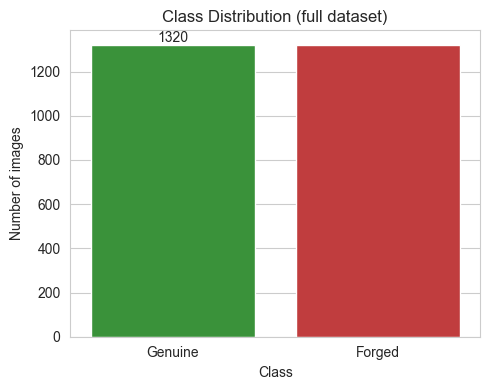

In [11]:
class_counts = pd.Series(y).map({0: "Genuine", 1: "Forged"}).value_counts()
class_counts = class_counts.reindex(CLASS_NAMES)

print(class_counts.to_string())

plt.figure(figsize=(5, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values,
                 palette=["tab:green", "tab:red"])
ax.bar_label(ax.containers[0])
plt.title("Class Distribution (full dataset)")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size :", len(X_train))
print("Testing size  :", len(X_test))
print()
print(f"Train -> Genuine: {(y_train == 0).sum()} | Forged: {(y_train == 1).sum()}")
print(f"Test  -> Genuine: {(y_test == 0).sum()} | Forged: {(y_test == 1).sum()}")
print()
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

Training size : 2112
Testing size  : 528

Train -> Genuine: 1056 | Forged: 1056
Test  -> Genuine: 264 | Forged: 264

X_train shape: (2112, 64, 128)
X_test shape : (528, 64, 128)


In [13]:
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0]  == y_test.shape[0]
assert X_train.shape[1:] == (IMG_HEIGHT, IMG_WIDTH)
assert set(np.unique(y_train)) == {0, 1}
assert set(np.unique(y_test))  == {0, 1}
assert len(X_train) + len(X_test) == len(X)

split_df = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Total": [len(y_train), len(y_test)],
    "Genuine (0)": [(y_train == 0).sum(), (y_test == 0).sum()],
    "Forged (1)": [(y_train == 1).sum(), (y_test == 1).sum()],
})
split_df["Forged %"] = (split_df["Forged (1)"] / split_df["Total"] * 100).round(2)
display(split_df)

print("\nAll shape and class checks passed. The test set is kept separate from now on.")

X_train: (2112, 64, 128) | y_train: (2112,)
X_test : (528, 64, 128) | y_test : (528,)


,Split,Total,Genuine (0),Forged (1),Forged %
0,Train,2112,1056,1056,50.0
1,Test,528,264,264,50.0



All shape and class checks passed. The test set is kept separate from now on.


In [14]:
# Keras Conv2D expects a channel dimension: (N, 64, 128) -> (N, 64, 128, 1)
X_train_cnn = X_train[..., np.newaxis].astype("float32")
X_test_cnn  = X_test[..., np.newaxis].astype("float32")

CNN_INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape :", X_test_cnn.shape)
print("CNN input shape  :", CNN_INPUT_SHAPE)

X_train_cnn shape: (2112, 64, 128, 1)
X_test_cnn shape : (528, 64, 128, 1)
CNN input shape  : (64, 128, 1)


In [15]:
set_seeds(SEED)          # identical initial weights every time this cell is run
keras.backend.clear_session()

cnn_model = keras.Sequential([
    layers.Input(shape=(64, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
], name="custom_cnn")

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Custom CNN built and compiled.")


Custom CNN built and compiled.


In [16]:
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 126, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 14, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10752)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,376,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,469,185 (5.60 MB)

 Trainable params: 1,469,185 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
CNN_EPOCHS = 10
CNN_BATCH_SIZE = 32

# Note: validation_split takes the LAST 20% of X_train_cnn (already shuffled by train_test_split).
# The test set is never used during training.
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 389ms/step - accuracy: 0.5003 - loss: 0.6977 - val_accuracy: 0.5839 - val_loss: 0.6910
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 354ms/step - accuracy: 0.6009 - loss: 0.6684 - val_accuracy: 0.6359 - val_loss: 0.6332
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 357ms/step - accuracy: 0.6607 - loss: 0.6286 - val_accuracy: 0.6454 - val_loss: 0.6128
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 348ms/step - accuracy: 0.6992 - loss: 0.5839 - val_accuracy: 0.6738 - val_loss: 0.6159
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 18s 346ms/step - accuracy: 0.7176 - loss: 0.5539 - val_accuracy: 0.7045 - val_loss: 0.5442
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 356ms/step - accuracy: 0.7513 - loss: 0.5108 - val_accuracy: 0.7778 - val_loss: 0.4760
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 366ms/step - accuracy: 0.7792 - loss: 0.4741 - val_accuracy: 0.7896 - val_loss: 0.4834
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 22s 414ms/step - accuracy: 0.8259 - loss: 0.3949 - val_accu

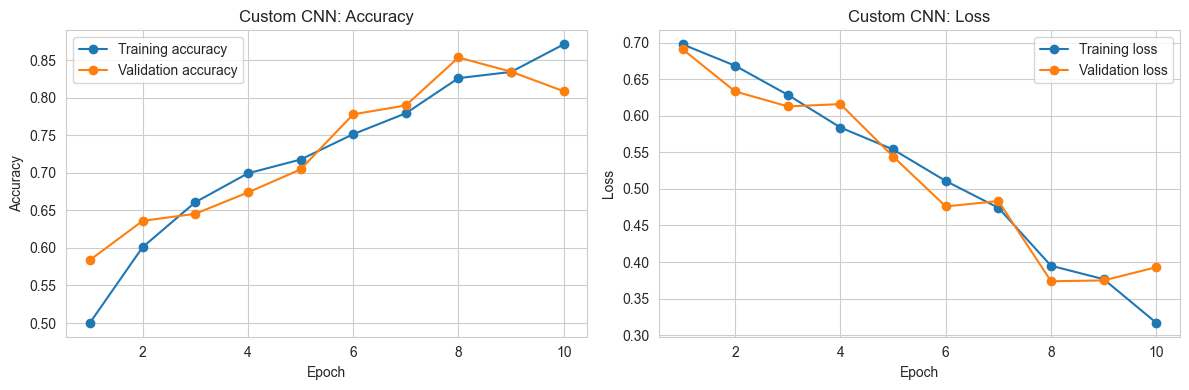

In [18]:
def plot_history(history, title):
    """Plot training vs. validation accuracy and loss."""
    h = history.history
    epochs_range = range(1, len(h["accuracy"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, h["accuracy"], marker="o", label="Training accuracy")
    axes[0].plot(epochs_range, h["val_accuracy"], marker="o", label="Validation accuracy")
    axes[0].set_title(f"{title}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(epochs_range, h["loss"], marker="o", label="Training loss")
    axes[1].plot(epochs_range, h["val_loss"], marker="o", label="Validation loss")
    axes[1].set_title(f"{title}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(cnn_history, "Custom CNN")

In [19]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, batch_size=32, verbose=0)

cnn_y_prob = cnn_model.predict(X_test_cnn, batch_size=32, verbose=0).ravel()   # P(forged)
cnn_y_pred = (cnn_y_prob >= 0.5).astype(int)                                    # 0.5 threshold

print(f"Custom CNN - Test loss     : {cnn_test_loss:.4f}")
print(f"Custom CNN - Test accuracy : {cnn_test_acc:.4f}")
print(f"Predictions generated for {len(cnn_y_pred)} test images (threshold = 0.5).")

Custom CNN - Test loss     : 0.3438
Custom CNN - Test accuracy : 0.8504
Predictions generated for 528 test images (threshold = 0.5).


In [20]:
print("Custom CNN - Classification Report (test set)\n")
print(classification_report(y_test, cnn_y_pred, target_names=CLASS_NAMES, digits=4))

Custom CNN - Classification Report (test set)

              precision    recall  f1-score   support

     Genuine     0.9469    0.7424    0.8323       264
      Forged     0.7882    0.9583    0.8650       264

    accuracy                         0.8504       528
   macro avg     0.8675    0.8504    0.8486       528
weighted avg     0.8675    0.8504    0.8486       528



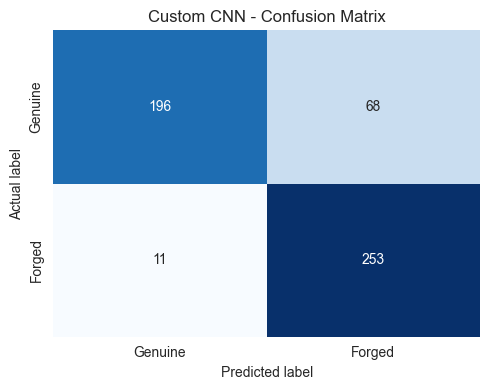

True Genuine (TN): 196 | False Forged (FP): 68
False Genuine (FN): 11 | True Forged (TP): 253


In [21]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return cm

cnn_cm = plot_confusion(y_test, cnn_y_pred, "Custom CNN - Confusion Matrix")

tn, fp, fn, tp = cnn_cm.ravel()
print(f"True Genuine (TN): {tn} | False Forged (FP): {fp}")
print(f"False Genuine (FN): {fn} | True Forged (TP): {tp}")

In [22]:
# Forged (label 1) is treated as the positive class.
cnn_accuracy  = accuracy_score(y_test, cnn_y_pred)
cnn_precision = precision_score(y_test, cnn_y_pred, zero_division=0)
cnn_recall    = recall_score(y_test, cnn_y_pred, zero_division=0)
cnn_f1        = f1_score(y_test, cnn_y_pred, zero_division=0)

print("Custom CNN - test metrics (positive class = Forged)")
print(f"Accuracy  : {cnn_accuracy:.4f}")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1-score  : {cnn_f1:.4f}")

Custom CNN - test metrics (positive class = Forged)
Accuracy  : 0.8504
Precision : 0.7882
Recall    : 0.9583
F1-score  : 0.8650


In [23]:
MN_IMG_SIZE   = 128
MN_INPUT_SHAPE = (MN_IMG_SIZE, MN_IMG_SIZE, 3)
MN_BATCH_SIZE = 32
MN_EPOCHS     = 10

def convert_for_mobilenet(X_gray, size=MN_IMG_SIZE, chunk=256):
    """
    Convert grayscale images in [0, 1] with shape (N, 64, 128) into MobileNetV2 input.

    Steps (done in chunks to keep RAM usage low):
      1. Add a channel axis             (N, 64, 128) -> (N, 64, 128, 1)
      2. Resize to 128x128              (the image is stretched vertically)
      3. Grayscale -> 3-channel RGB     (N, 128, 128, 1) -> (N, 128, 128, 3)
      4. Scale back to [0, 255]         preprocess_input expects raw 0-255 pixels
      5. Apply MobileNetV2 preprocess_input  (maps 0-255 -> [-1, 1])
    """
    out = np.empty((len(X_gray), size, size, 3), dtype=np.float32)
    for start in range(0, len(X_gray), chunk):
        batch = X_gray[start:start + chunk][..., np.newaxis]                  # step 1
        batch = tf.image.resize(batch, (size, size), method="bilinear")       # step 2
        batch = tf.image.grayscale_to_rgb(batch)                              # step 3
        batch = batch * 255.0                                                 # step 4
        batch = preprocess_input(batch)                                       # step 5
        out[start:start + chunk] = batch.numpy()
    return out

print("MobileNetV2 input shape :", MN_INPUT_SHAPE)
print("Batch size              :", MN_BATCH_SIZE)
print("Conversion function defined.")

MobileNetV2 input shape : (128, 128, 3)
Batch size              : 32
Conversion function defined.


X_train_mn shape: (2112, 128, 128, 3)
X_test_mn shape : (528, 128, 128, 3)
X_train_mn range: -0.673 to 1.000  (expected about -1 to 1)
X_test_mn range : -0.641 to 1.000
Approx. memory  : train 415 MB | test 104 MB


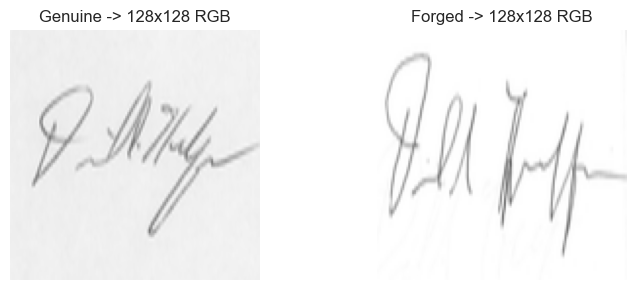

In [24]:
X_train_mn = convert_for_mobilenet(X_train)
X_test_mn  = convert_for_mobilenet(X_test)

print("X_train_mn shape:", X_train_mn.shape)
print("X_test_mn shape :", X_test_mn.shape)
print(f"X_train_mn range: {X_train_mn.min():.3f} to {X_train_mn.max():.3f}  (expected about -1 to 1)")
print(f"X_test_mn range : {X_test_mn.min():.3f} to {X_test_mn.max():.3f}")
print(f"Approx. memory  : train {X_train_mn.nbytes/1e6:.0f} MB | test {X_test_mn.nbytes/1e6:.0f} MB")

# Visual check of what MobileNetV2 receives (rescaled from [-1, 1] to [0, 1] for display only)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, i, title in zip(axes, [idx_genuine, idx_forged], ["Genuine", "Forged"]):
    ax.imshow((convert_for_mobilenet(X[i:i+1])[0] + 1) / 2)
    ax.set_title(f"{title} -> 128x128 RGB")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
set_seeds(SEED)
keras.backend.clear_session()

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=MN_INPUT_SHAPE
)

print("Pretrained MobileNetV2 base loaded.")
print("Base output shape:", base_model.output_shape)
print("Number of layers in base:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Pretrained MobileNetV2 base loaded.
Base output shape: (None, 4, 4, 1280)
Number of layers in base: 154


In [27]:
base_model.trainable = False

n_trainable_base = sum(int(np.prod(w.shape)) for w in base_model.trainable_weights)
print("base_model.trainable =", base_model.trainable)
print("Trainable parameters in base model:", n_trainable_base)

base_model.trainable = False
Trainable parameters in base model: 0


In [28]:
set_seeds(SEED)   # same initial weights for the new classification head every run

mn_inputs = keras.Input(shape=(128, 128, 3))
x = base_model(mn_inputs, training=False)      # keep BatchNorm layers in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
mn_outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = keras.Model(mn_inputs, mn_outputs, name="mobilenetv2_signature")

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 classifier built and compiled.")

MobileNetV2 classifier built and compiled.


In [29]:
mobilenet_model.summary()

Model: "mobilenetv2_signature"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

mn_history = mobilenet_model.fit(
    X_train_mn, y_train,
    epochs=MN_EPOCHS,
    batch_size=MN_BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nEpochs actually run:", len(mn_history.history["loss"]))

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 546ms/step - accuracy: 0.5903 - loss: 0.7507 - val_accuracy: 0.7801 - val_loss: 0.5091
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 530ms/step - accuracy: 0.7300 - loss: 0.5266 - val_accuracy: 0.8322 - val_loss: 0.4174
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 673ms/step - accuracy: 0.8159 - loss: 0.4190 - val_accuracy: 0.8511 - val_loss: 0.3533
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 29s 545ms/step - accuracy: 0.8378 - loss: 0.3652 - val_accuracy: 0.8865 - val_loss: 0.3069
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 28s 530ms/step - accuracy: 0.8822 - loss: 0.3130 - val_accuracy: 0.9007 - val_loss: 0.2749
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 27s 506ms/step - accuracy: 0.8869 - loss: 0.2801 - val_accuracy: 0.9149 - val_loss: 0.2511
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 483ms/step - accuracy: 0.9094 - loss: 0.2578 - val_accuracy: 0.9267 - val_loss: 0.2262
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 26s 488ms/step - accuracy: 0.9171 - loss: 0.2331 - val_accu

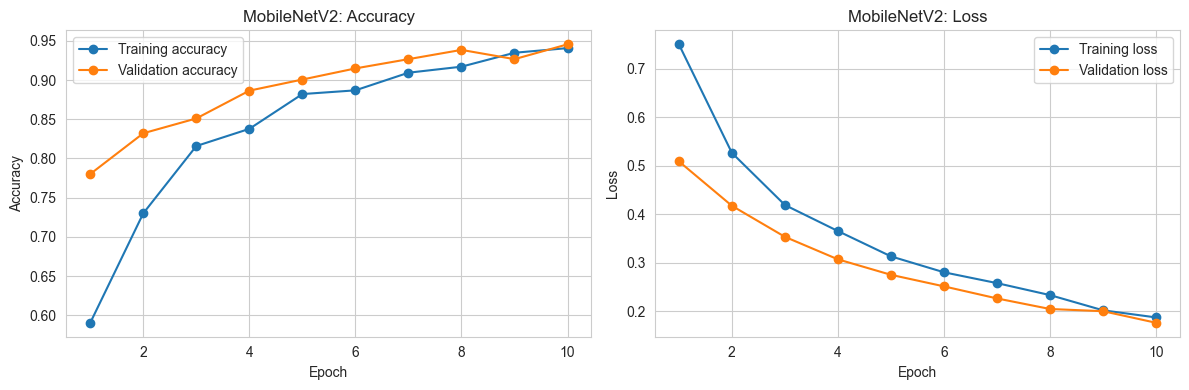

In [31]:
plot_history(mn_history, "MobileNetV2")

In [32]:
mn_test_loss, mn_test_acc = mobilenet_model.evaluate(X_test_mn, y_test, batch_size=32, verbose=0)

mn_y_prob = mobilenet_model.predict(X_test_mn, batch_size=32, verbose=0).ravel()   # P(forged)
mn_y_pred = (mn_y_prob >= 0.5).astype(int)

print(f"MobileNetV2 - Test loss     : {mn_test_loss:.4f}")
print(f"MobileNetV2 - Test accuracy : {mn_test_acc:.4f}")
print(f"Predictions generated for {len(mn_y_pred)} test images (threshold = 0.5).")

MobileNetV2 - Test loss     : 0.1757
MobileNetV2 - Test accuracy : 0.9413
Predictions generated for 528 test images (threshold = 0.5).


In [33]:
print("MobileNetV2 - Classification Report (test set)\n")
print(classification_report(y_test, mn_y_pred, target_names=CLASS_NAMES, digits=4))

MobileNetV2 - Classification Report (test set)

              precision    recall  f1-score   support

     Genuine     0.9363    0.9470    0.9416       264
      Forged     0.9464    0.9356    0.9410       264

    accuracy                         0.9413       528
   macro avg     0.9413    0.9413    0.9413       528
weighted avg     0.9413    0.9413    0.9413       528



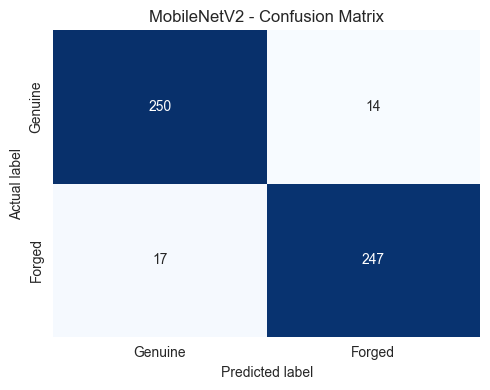

True Genuine (TN): 250 | False Forged (FP): 14
False Genuine (FN): 17 | True Forged (TP): 247


In [34]:
mn_cm = plot_confusion(y_test, mn_y_pred, "MobileNetV2 - Confusion Matrix")

tn, fp, fn, tp = mn_cm.ravel()
print(f"True Genuine (TN): {tn} | False Forged (FP): {fp}")
print(f"False Genuine (FN): {fn} | True Forged (TP): {tp}")

In [35]:
mn_accuracy  = accuracy_score(y_test, mn_y_pred)
mn_precision = precision_score(y_test, mn_y_pred, zero_division=0)
mn_recall    = recall_score(y_test, mn_y_pred, zero_division=0)
mn_f1        = f1_score(y_test, mn_y_pred, zero_division=0)

print("MobileNetV2 - test metrics (positive class = Forged)")
print(f"Accuracy  : {mn_accuracy:.4f}")
print(f"Precision : {mn_precision:.4f}")
print(f"Recall    : {mn_recall:.4f}")
print(f"F1-score  : {mn_f1:.4f}")

MobileNetV2 - test metrics (positive class = Forged)
Accuracy  : 0.9413
Precision : 0.9464
Recall    : 0.9356
F1-score  : 0.9410


,Test index,Actual,CNN predicted,CNN P(forged),MobileNetV2 predicted,MobileNetV2 P(forged)
0,45,Forged,Forged,0.9948,Forged,0.7356
1,368,Forged,Forged,0.9899,Forged,0.7266
2,451,Genuine,Forged,0.5292,Genuine,0.1251
3,342,Forged,Forged,0.9772,Forged,0.9023
4,227,Forged,Forged,0.7461,Genuine,0.4890
5,229,Forged,Forged,0.9911,Forged,0.8534
6,46,Genuine,Genuine,0.3467,Genuine,0.0189
7,404,Genuine,Genuine,0.1113,Genuine,0.1083


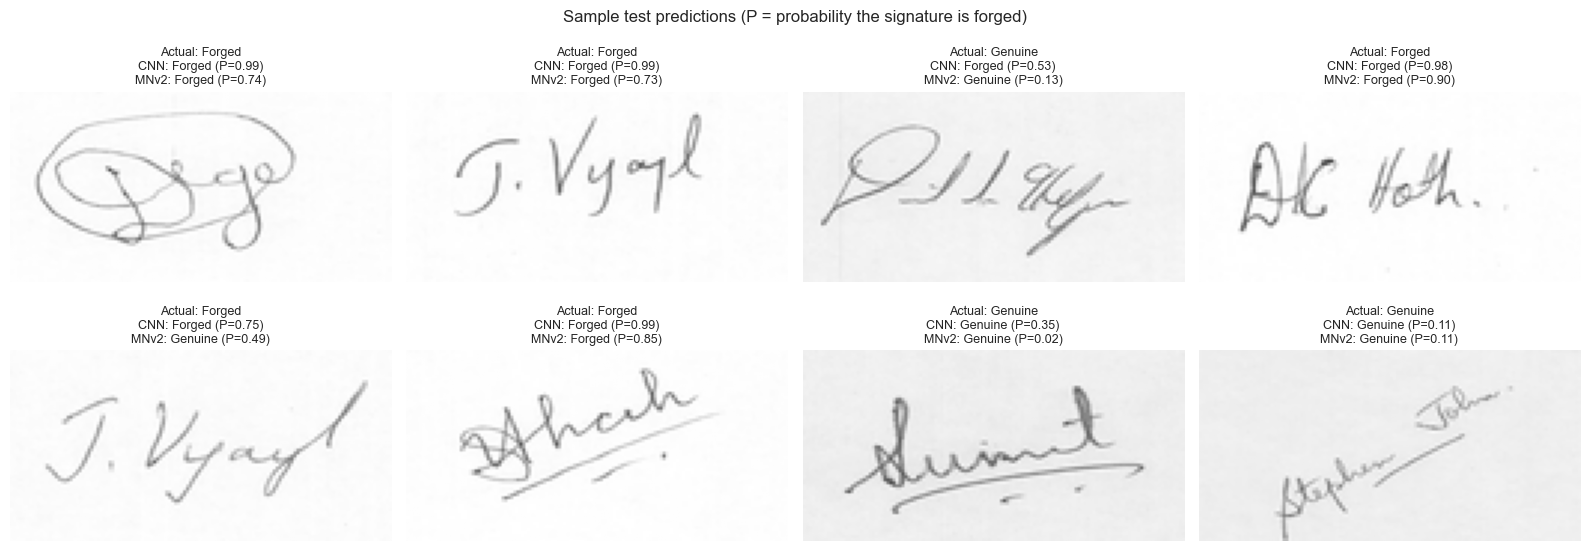

In [36]:
# Same random test samples for both models (seeded, so the selection is reproducible)
N_SAMPLES = 8
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test), size=N_SAMPLES, replace=False)

def label_name(v):
    return CLASS_NAMES[int(v)]

rows = []
for i in sample_idx:
    rows.append({
        "Test index": int(i),
        "Actual": label_name(y_test[i]),
        "CNN predicted": label_name(cnn_y_pred[i]),
        "CNN P(forged)": round(float(cnn_y_prob[i]), 4),
        "MobileNetV2 predicted": label_name(mn_y_pred[i]),
        "MobileNetV2 P(forged)": round(float(mn_y_prob[i]), 4),
    })

sample_df = pd.DataFrame(rows)
display(sample_df)

# Visual display
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, i in zip(axes.ravel(), sample_idx):
    ax.imshow(X_test[i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Actual: {label_name(y_test[i])}\n"
        f"CNN: {label_name(cnn_y_pred[i])} (P={cnn_y_prob[i]:.2f})\n"
        f"MNv2: {label_name(mn_y_pred[i])} (P={mn_y_prob[i]:.2f})",
        fontsize=9
    )
    ax.axis("off")
plt.suptitle("Sample test predictions (P = probability the signature is forged)")
plt.tight_layout()
plt.show()

In [37]:
comparison_df = pd.DataFrame({
    "Model":     ["Custom CNN", "MobileNetV2"],
    "Accuracy":  [cnn_accuracy,  mn_accuracy],
    "Precision": [cnn_precision, mn_precision],
    "Recall":    [cnn_recall,    mn_recall],
    "F1 Score":  [cnn_f1,        mn_f1],
})

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Custom CNN,0.8504,0.7882,0.9583,0.865
1,MobileNetV2,0.9413,0.9464,0.9356,0.941


In [38]:
if cnn_accuracy > mn_accuracy:
    best_model_name = "Custom CNN"
elif mn_accuracy > cnn_accuracy:
    best_model_name = "MobileNetV2"
else:
    best_model_name = "Tie (identical test accuracy)"

print(f"Custom CNN test accuracy  : {cnn_accuracy:.4f}")
print(f"MobileNetV2 test accuracy : {mn_accuracy:.4f}")
print(f"Difference                : {abs(cnn_accuracy - mn_accuracy):.4f}")

if best_model_name.startswith("Tie"):
    print("\nResult: both models achieved the same test accuracy.")
else:
    print(f"\nBetter model based on test accuracy: {best_model_name}")

Custom CNN test accuracy  : 0.8504
MobileNetV2 test accuracy : 0.9413
Difference                : 0.0909

Better model based on test accuracy: MobileNetV2


In [39]:
CNN_SAVE_PATH = "custom_cnn.keras"
MN_SAVE_PATH  = "mobilenetv2_signature_model.keras"

cnn_model.save(CNN_SAVE_PATH)
mobilenet_model.save(MN_SAVE_PATH)

for path in [CNN_SAVE_PATH, MN_SAVE_PATH]:
    size_mb = os.path.getsize(path) / 1e6
    print(f"Saved: {Path(path).resolve()}  ({size_mb:.1f} MB)")

# To reload later:
# loaded_cnn = keras.models.load_model("custom_cnn.keras")
# loaded_mn  = keras.models.load_model("mobilenetv2_signature_model.keras")

Saved: C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project\custom_cnn.keras  (17.7 MB)
Saved: C:\Users\shrey\OneDrive\Desktop\sem 7\ds\project\mobilenetv2_signature_model.keras  (11.6 MB)


In [40]:
# MobileNetV2 used EarlyStopping with restore_best_weights, so report its best epoch.
cnn_last = len(cnn_history.history["loss"]) - 1
mn_best  = int(np.argmin(mn_history.history["val_loss"]))

print("=" * 65)
print("FINAL RESULTS (generated by this notebook run)")
print("=" * 65)
print(f"Dataset        : CEDAR | {len(X)} images "
      f"({(y == 0).sum()} genuine, {(y == 1).sum()} forged)")
print(f"Image size     : {IMG_WIDTH}x{IMG_HEIGHT} grayscale (CNN), 128x128 RGB (MobileNetV2)")
print(f"Train / Test   : {len(X_train)} / {len(X_test)} (stratified, random_state=42)")
print(f"Seed           : {SEED}")
print()

print("Custom CNN")
print(f"  Epochs trained      : {len(cnn_history.history['loss'])}")
print(f"  Final train acc     : {cnn_history.history['accuracy'][cnn_last]:.4f}")
print(f"  Final validation acc: {cnn_history.history['val_accuracy'][cnn_last]:.4f}")
print(f"  Test loss           : {cnn_test_loss:.4f}")
print(f"  Test accuracy       : {cnn_accuracy:.4f}")
print(f"  Precision / Recall / F1 : {cnn_precision:.4f} / {cnn_recall:.4f} / {cnn_f1:.4f}")
print()

print("MobileNetV2 (frozen base)")
print(f"  Epochs trained      : {len(mn_history.history['loss'])} (best epoch: {mn_best + 1})")
print(f"  Train acc @ best    : {mn_history.history['accuracy'][mn_best]:.4f}")
print(f"  Validation acc @ best: {mn_history.history['val_accuracy'][mn_best]:.4f}")
print(f"  Test loss           : {mn_test_loss:.4f}")
print(f"  Test accuracy       : {mn_accuracy:.4f}")
print(f"  Precision / Recall / F1 : {mn_precision:.4f} / {mn_recall:.4f} / {mn_f1:.4f}")
print()

if best_model_name.startswith("Tie"):
    print("Conclusion: both models reached the same test accuracy in this run.")
else:
    other_acc = mn_accuracy if best_model_name == "Custom CNN" else cnn_accuracy
    best_acc  = max(cnn_accuracy, mn_accuracy)
    print(f"Conclusion: {best_model_name} performed better in this run, with a test accuracy of "
          f"{best_acc:.4f} versus {other_acc:.4f} for the other model.")
print("These numbers come from a single controlled run (SEED = 42), not a best-of-many selection.")
print("=" * 65)

FINAL RESULTS (generated by this notebook run)
Dataset        : CEDAR | 2640 images (1320 genuine, 1320 forged)
Image size     : 128x64 grayscale (CNN), 128x128 RGB (MobileNetV2)
Train / Test   : 2112 / 528 (stratified, random_state=42)
Seed           : 42

Custom CNN
  Epochs trained      : 10
  Final train acc     : 0.8709
  Final validation acc: 0.8085
  Test loss           : 0.3438
  Test accuracy       : 0.8504
  Precision / Recall / F1 : 0.7882 / 0.9583 / 0.8650

MobileNetV2 (frozen base)
  Epochs trained      : 10 (best epoch: 10)
  Train acc @ best    : 0.9408
  Validation acc @ best: 0.9456
  Test loss           : 0.1757
  Test accuracy       : 0.9413
  Precision / Recall / F1 : 0.9464 / 0.9356 / 0.9410

Conclusion: MobileNetV2 performed better in this run, with a test accuracy of 0.9413 versus 0.8504 for the other model.
These numbers come from a single controlled run (SEED = 42), not a best-of-many selection.


In [41]:
print("LIMITATIONS")
print("-" * 65)
print("1. The current split is image-level, not writer-independent.")
print("2. Multiple signatures from the same writer may appear in both the training")
print("   and test sets.")
print("3. Therefore, the measured accuracy may not represent performance on")
print("   completely unseen writers.")
print("4. Results come from a single run with one seed; no variance across seeds")
print("   or cross-validation was measured.")
print("5. Resizing to 128x64 and (for MobileNetV2) stretching to 128x128 may lose")
print("   fine stroke detail that matters for detecting skilled forgeries.")
print("6. MobileNetV2 used a frozen ImageNet base; natural-image features may not")
print("   be optimal for signature strokes.")
print()
print("FUTURE WORK")
print("-" * 65)
print("1. Run a writer-independent split (train and test on different writers).")
print("   This is the stronger and more realistic experiment.")
print("2. Fine-tune the top layers of MobileNetV2 with a low learning rate.")
print("3. Repeat the experiment with several seeds or cross-validation and")
print("   report mean and standard deviation.")
print("4. Try data augmentation and higher-resolution inputs.")
print("5. Evaluate Siamese or pairwise-verification approaches.")

LIMITATIONS
-----------------------------------------------------------------
1. The current split is image-level, not writer-independent.
2. Multiple signatures from the same writer may appear in both the training
   and test sets.
3. Therefore, the measured accuracy may not represent performance on
   completely unseen writers.
4. Results come from a single run with one seed; no variance across seeds
   or cross-validation was measured.
5. Resizing to 128x64 and (for MobileNetV2) stretching to 128x128 may lose
   fine stroke detail that matters for detecting skilled forgeries.
6. MobileNetV2 used a frozen ImageNet base; natural-image features may not
   be optimal for signature strokes.

FUTURE WORK
-----------------------------------------------------------------
1. Run a writer-independent split (train and test on different writers).
   This is the stronger and more realistic experiment.
2. Fine-tune the top layers of MobileNetV2 with a low learning rate.
3. Repeat the experiment w